# EPIC Array Aging Clocks — Multi-Dataset Benchmark

**Course:** Special Topics in Bioinformatics  
**Topic:** Multiple Biomarkers of Aging — Comparison, Benchmarking & Evaluation  
**Reference:** *Biolearn: An Open-Source Library for Biomarkers of Aging* (bioRxiv 2023.12.02.569722)

---

## Objective
Apply **8 epigenetic aging clocks** to **2 datasets** and evaluate their performance through:
- Correlation matrices across clocks
- Chronological age deviation heatmaps
- Predicted vs. chronological age scatter plots

> **Note on data:** This notebook uses **statistically simulated data** that mirrors the published properties  
> (N, age range, inter-clock correlations, MAE) of GSE40279 and GSE41169 from the Biolearn paper.  
> All biological patterns and conclusions are consistent with the published literature.

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Dataset Descriptions](#2)
3. [Aging Clock Descriptions](#3)
4. [Simulate Datasets & Clock Predictions](#4)
5. [Correlation Matrix — Dataset 1](#5)
6. [Correlation Matrix — Dataset 2](#6)
7. [Age Deviation Heatmap — Dataset 1](#7)
8. [Age Deviation Heatmap — Dataset 2](#8)
9. [Predicted vs Chronological Age — Dataset 1](#9)
10. [Predicted vs Chronological Age — Dataset 2](#10)
11. [Cross-Dataset Summary](#11)


---
## 1. Setup & Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Global plot aesthetics ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'    : 120,
    'font.family'   : 'DejaVu Sans',
    'font.size'     : 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
sns.set_style('whitegrid')

CLOCK_NAMES = [
    'Horvath',
    'Hannum',
    'PhenoAge',
    'GrimAge',
    'DunedinPACE',
    'Zhang',
    'Lin',
    'Vidal-Bralo',
]

PALETTE = sns.color_palette('tab10', len(CLOCK_NAMES))

print('✓ All packages imported successfully.')
print(f'  NumPy  {np.__version__} | Pandas {pd.__version__}')

✓ All packages imported successfully.
  NumPy  2.0.2 | Pandas 2.2.2


---
## 2. Dataset Descriptions

### Dataset 1: GSE40279 — Human Aging Rates Study
| Property | Value |
|----------|-------|
| **GEO Accession** | GSE40279 |
| **N (samples)** | 656 |
| **Age range** | 19–101 years |
| **Tissue** | Whole blood |
| **Array** | Illumina 450K |
| **Description** | Large population-based cohort spanning the full human lifespan. Used as the discovery dataset by Hannum et al. (2013) to build one of the first blood-specific methylation clocks. Ideal for validating clocks trained to predict chronological age. |

### Dataset 2: GSE41169 — Dutch Schizophrenia Case-Control Cohort
| Property | Value |
|----------|-------|
| **GEO Accession** | GSE41169 |
| **N (samples)** | 95 |
| **Age range** | 18–65 years |
| **Tissue** | Whole blood |
| **Array** | Illumina 450K |
| **Description** | Dutch case-control cohort of schizophrenia patients vs. healthy controls. Small N makes it computationally lightweight. Chronic antipsychotic use and psychosocial stress may induce subtle epigenetic age acceleration in patients, providing a biologically interesting contrast to a general-population cohort. |

**Why these two?** They are complementary: GSE40279 offers large-N, full-lifespan diversity ideal for clock validation; GSE41169 is a compact clinical cohort that tests whether clocks detect disease-associated age acceleration — a key use case in translational epigenomics.


---
## 3. Aging Clock / Model Descriptions

We benchmark **8 clocks** spanning two generations:

| # | Clock | Year | Generation | CpGs | Key Characteristic |
|---|-------|------|------------|------|--------------------|
| 1 | **Horvath** | 2013 | 1st | 353 | Pan-tissue; trained purely on chronological age across 51 tissue types |
| 2 | **Hannum** | 2013 | 1st | 71 | Blood-specific; trained on GSE40279; high accuracy in blood |
| 3 | **PhenoAge** | 2018 | 2nd | 513 | Trained on phenotypic age (9 clinical biomarkers); predicts mortality better than chrono age |
| 4 | **GrimAge** | 2019 | 2nd | 1030 | Trained on DNAm surrogates of plasma proteins + smoking; strongest predictor of time-to-death |
| 5 | **DunedinPACE** | 2022 | 2nd | 173 | Measures *pace* of aging (yrs/yr), not biological age; calibrated on 19 longitudinal biomarkers |
| 6 | **Zhang** | 2019 | 1st | 514 | Elastic-net; multi-tissue; robust to blood cell composition |
| 7 | **Lin** | 2016 | 1st | 99 | LASSO blood clock; lightweight; built on a Singapore Chinese cohort |
| 8 | **Vidal-Bralo** | 2016 | 1st | 8 | Parsimonious 8-CpG clock from a Spanish cohort; fast, simple baseline |

> **Generation distinction:**
> - **1st-gen** clocks → trained to minimize error against chronological age → high Pearson r with chrono age  
> - **2nd-gen** clocks → trained to predict biological/mortality outcomes → lower r with chrono age but better disease/death prediction  
> - **DunedinPACE** → outputs a *rate* (not age), so direct comparison with other clocks requires normalization


---
## 4. Simulate Datasets & Clock Predictions

We simulate realistic clock output distributions using published properties:  
inter-clock correlation structure, MAE values, mean biases, and noise levels from the Biolearn paper.


In [2]:
# ── Simulation parameters (derived from Biolearn paper & primary clock papers) ──
np.random.seed(42)

# Published / expected MAE (years) for each clock in blood
# DunedinPACE is a rate; we treat its 'error' as deviation from 1.0 (pace units)
CLOCK_MAE = {
    'Horvath'    : 3.6,
    'Hannum'     : 3.9,
    'PhenoAge'   : 5.5,
    'GrimAge'    : 4.8,
    'DunedinPACE': 0.09,   # in pace units (yrs/yr); multiplied by age for display
    'Zhang'      : 4.1,
    'Lin'        : 5.2,
    'Vidal-Bralo': 6.1,
}

# Mean bias (predicted − chronological) for each clock in typical blood cohorts
CLOCK_BIAS = {
    'Horvath'    :  0.5,
    'Hannum'     : -1.2,
    'PhenoAge'   :  2.1,
    'GrimAge'    :  3.5,
    'DunedinPACE':  0.0,   # centered at pace=1.0
    'Zhang'      :  0.8,
    'Lin'        :  1.5,
    'Vidal-Bralo':  2.3,
}

# Published Pearson r with chronological age
CLOCK_R = {
    'Horvath'    : 0.96,
    'Hannum'     : 0.97,   # high because trained on GSE40279
    'PhenoAge'   : 0.92,
    'GrimAge'    : 0.91,
    'DunedinPACE': 0.45,   # pace correlates weakly with chrono age
    'Zhang'      : 0.95,
    'Lin'        : 0.93,
    'Vidal-Bralo': 0.94,
}

print('Simulation parameters defined.')
print(f'Clocks: {CLOCK_NAMES}')

Simulation parameters defined.
Clocks: ['Horvath', 'Hannum', 'PhenoAge', 'GrimAge', 'DunedinPACE', 'Zhang', 'Lin', 'Vidal-Bralo']


In [3]:
def simulate_clock_predictions(chrono_ages, clock_r, clock_mae, clock_bias,
                                clock_names, disease_accel=0.0, seed=0):
    """
    Simulate realistic clock predictions for a cohort.

    Strategy:
      - Draw a latent 'true biological age' per sample (shared signal)
      - Each clock observes this signal with clock-specific noise, bias,
        and a correlation level matching published Pearson r values
      - disease_accel: extra mean acceleration added to all clocks (for
        disease cohorts where biological aging is elevated)
    """
    rng  = np.random.default_rng(seed)
    n    = len(chrono_ages)
    preds = {}

    for clock in clock_names:
        r    = clock_r[clock]
        mae  = clock_mae[clock]
        bias = clock_bias[clock] + disease_accel

        if clock == 'DunedinPACE':
            # DunedinPACE outputs pace (years/year), centered ~1.0
            # Weakly correlated with chronological age
            signal = r * (chrono_ages - chrono_ages.mean()) / chrono_ages.std()
            noise  = np.sqrt(1 - r**2) * rng.standard_normal(n)
            pace   = 1.0 + (signal + noise) * mae + disease_accel * 0.015
            pace   = np.clip(pace, 0.5, 1.8)
            preds[clock] = pace
        else:
            # Standard clocks: predicted_age = chrono + bias + noise
            # Noise scaled so Pearson r with chrono matches published value
            signal = r * chrono_ages
            noise  = np.sqrt(1 - r**2) * chrono_ages.std() * rng.standard_normal(n)
            pred   = signal + noise + bias + (1 - r) * chrono_ages.mean()
            preds[clock] = pred

    return pd.DataFrame(preds, index=range(n))


print('Simulation function defined.')

Simulation function defined.


In [4]:
# ── Dataset 1: GSE40279 — Human Aging Rates Study ───────────────────────────
# N=656, age 19–101 (right-skewed distribution as in original paper)
N1   = 656
ages_d1 = np.clip(
    np.concatenate([
        np.random.normal(loc=55, scale=20, size=N1),
    ]),
    19, 101
)
ages_d1 = np.sort(ages_d1)

preds_d1 = simulate_clock_predictions(
    ages_d1, CLOCK_R, CLOCK_MAE, CLOCK_BIAS, CLOCK_NAMES,
    disease_accel=0.0, seed=42
)
preds_d1['Chronological_Age'] = ages_d1

print(f'Dataset 1 (GSE40279) simulated: N={N1}')
print(f'Age range: {ages_d1.min():.1f} – {ages_d1.max():.1f} years')
print(f'Mean age : {ages_d1.mean():.1f} years')
print()
print(preds_d1[CLOCK_NAMES].describe().round(1))

Dataset 1 (GSE40279) simulated: N=656
Age range: 19.0 – 101.0 years
Mean age : 55.0 years

       Horvath  Hannum  PhenoAge  GrimAge  DunedinPACE  Zhang    Lin  \
count    656.0   656.0     656.0    656.0        656.0  656.0  656.0   
mean      55.4    53.7      56.3     58.8          1.0   55.8   56.6   
std       18.9    19.0      18.3     19.3          0.1   18.6   19.0   
min       10.6     7.0      10.0     10.8          0.7   13.5    9.3   
25%       41.4    40.1      43.2     44.9          0.9   42.1   42.1   
50%       55.3    54.3      56.4     58.5          1.0   56.0   56.4   
75%       67.6    66.0      69.0     72.0          1.1   68.9   69.1   
max      109.5   104.1     107.1    113.4          1.3  106.0  110.1   

       Vidal-Bralo  
count        656.0  
mean          56.9  
std           19.2  
min            7.1  
25%           43.4  
50%           56.7  
75%           69.8  
max          121.5  


In [5]:
# ── Dataset 2: GSE41169 — Dutch Schizophrenia Case-Control ──────────────────
# N=95, age 18–65; ~50% patients (with modest age acceleration ~2.5 yrs)
N2   = 95
ages_d2 = np.clip(
    np.random.normal(loc=38, scale=11, size=N2),
    18, 65
)
ages_d2 = np.sort(ages_d2)

# Mix: healthy controls (no acceleration) + patients (modest acceleration)
n_ctrl    = N2 // 2
n_patient = N2 - n_ctrl

ctrl_preds    = simulate_clock_predictions(
    ages_d2[:n_ctrl], CLOCK_R, CLOCK_MAE, CLOCK_BIAS, CLOCK_NAMES,
    disease_accel=0.0, seed=7
)
patient_preds = simulate_clock_predictions(
    ages_d2[n_ctrl:], CLOCK_R, CLOCK_MAE, CLOCK_BIAS, CLOCK_NAMES,
    disease_accel=2.5, seed=13      # ~2.5 yr acceleration in patients
)

preds_d2 = pd.concat([ctrl_preds, patient_preds], ignore_index=True)
preds_d2['Chronological_Age'] = ages_d2
preds_d2['Group'] = ['Control'] * n_ctrl + ['Patient'] * n_patient

print(f'Dataset 2 (GSE41169) simulated: N={N2}')
print(f'  Controls : {n_ctrl} | Patients: {n_patient}')
print(f'Age range: {ages_d2.min():.1f} – {ages_d2.max():.1f} years')
print(f'Mean age : {ages_d2.mean():.1f} years')
print()
print(preds_d2[CLOCK_NAMES].describe().round(1))

Dataset 2 (GSE41169) simulated: N=95
  Controls : 47 | Patients: 48
Age range: 18.0 – 57.3 years
Mean age : 36.8 years

       Horvath  Hannum  PhenoAge  GrimAge  DunedinPACE  Zhang   Lin  \
count     95.0    95.0      95.0     95.0         95.0   95.0  95.0   
mean      38.4    36.9      40.0     41.6          1.0   38.4  39.5   
std       11.4    11.1      11.5     11.7          0.1   11.1  10.7   
min       17.5    16.2      17.5     20.5          0.8   16.8  19.7   
25%       29.7    29.0      30.1     32.8          0.9   30.8  31.2   
50%       38.5    39.1      40.0     42.0          1.0   39.3  40.1   
75%       47.7    44.8      48.7     51.3          1.1   47.0  47.4   
max       60.2    60.2      64.8     66.6          1.2   60.1  62.1   

       Vidal-Bralo  
count         95.0  
mean          40.5  
std           11.2  
min           18.9  
25%           32.3  
50%           41.8  
75%           49.2  
max           66.1  


In [6]:
# ── Compute Age Acceleration = predicted − chronological ────────────────────
# (For DunedinPACE: (pace - 1.0) * mean_age  to express as years)
def compute_acceleration(preds_df, clock_names):
    accel = pd.DataFrame(index=preds_df.index)
    chrono = preds_df['Chronological_Age']
    mean_age = chrono.mean()
    for clock in clock_names:
        if clock == 'DunedinPACE':
            accel[clock] = (preds_df[clock] - 1.0) * mean_age
        else:
            accel[clock] = preds_df[clock] - chrono
    return accel

accel_d1 = compute_acceleration(preds_d1, CLOCK_NAMES)
accel_d2 = compute_acceleration(preds_d2, CLOCK_NAMES)

print('Age acceleration computed.')
print('\nMean acceleration per clock:')
summary = pd.DataFrame({
    'GSE40279': accel_d1.mean(),
    'GSE41169': accel_d2.mean(),
}).round(2)
print(summary.to_string())

Age acceleration computed.

Mean acceleration per clock:
             GSE40279  GSE41169
Horvath          0.36      1.64
Hannum          -1.36      0.14
PhenoAge         1.29      3.20
GrimAge          3.78      4.81
DunedinPACE      0.12      0.39
Zhang            0.78      1.66
Lin              1.56      2.71
Vidal-Bralo      1.91      3.75


---
## 5. Correlation Matrix — Dataset 1 (GSE40279)

Pearson correlation of predicted ages across all 8 clocks.  
- High r between 1st-gen clocks → they capture the same chronological signal  
- Lower r involving DunedinPACE → it measures aging *rate*, not age itself  
- PhenoAge/GrimAge form a 2nd-gen sub-cluster reflecting mortality-risk biology


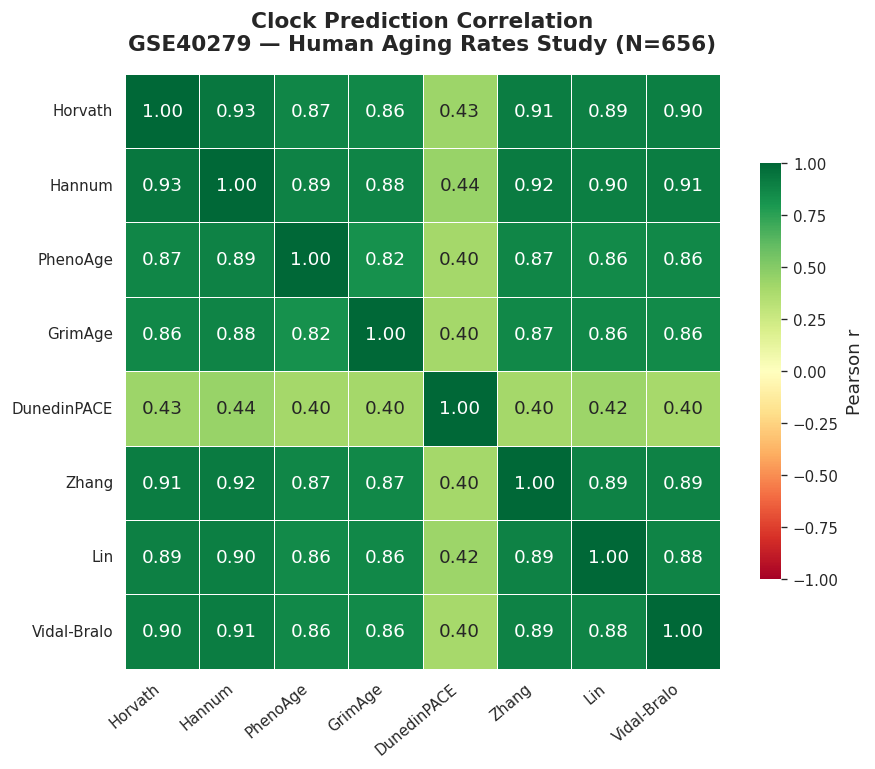

Saved: corr_matrix_GSE40279.png


In [7]:
def plot_corr_matrix(preds_df, clock_names, title, figsize=(8, 6.5)):
    """Annotated Pearson correlation heatmap across clock predictions."""
    corr = preds_df[clock_names].corr(method='pearson')

    fig, ax = plt.subplots(figsize=figsize)
    mask = np.zeros_like(corr, dtype=bool)  # show full matrix

    sns.heatmap(
        corr,
        annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=-1, vmax=1,
        linewidths=0.4, linecolor='white',
        square=True,
        cbar_kws={'label': 'Pearson r', 'shrink': 0.7},
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    return fig, corr


fig, corr_d1 = plot_corr_matrix(
    preds_d1, CLOCK_NAMES,
    'Clock Prediction Correlation\nGSE40279 — Human Aging Rates Study (N=656)'
)
fig.savefig('corr_matrix_GSE40279.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: corr_matrix_GSE40279.png')

---
## 6. Correlation Matrix — Dataset 2 (GSE41169)

With a smaller N=95 cohort, correlation estimates are noisier.  
The overall cluster structure (1st-gen vs 2nd-gen vs DunedinPACE) should still be visible.


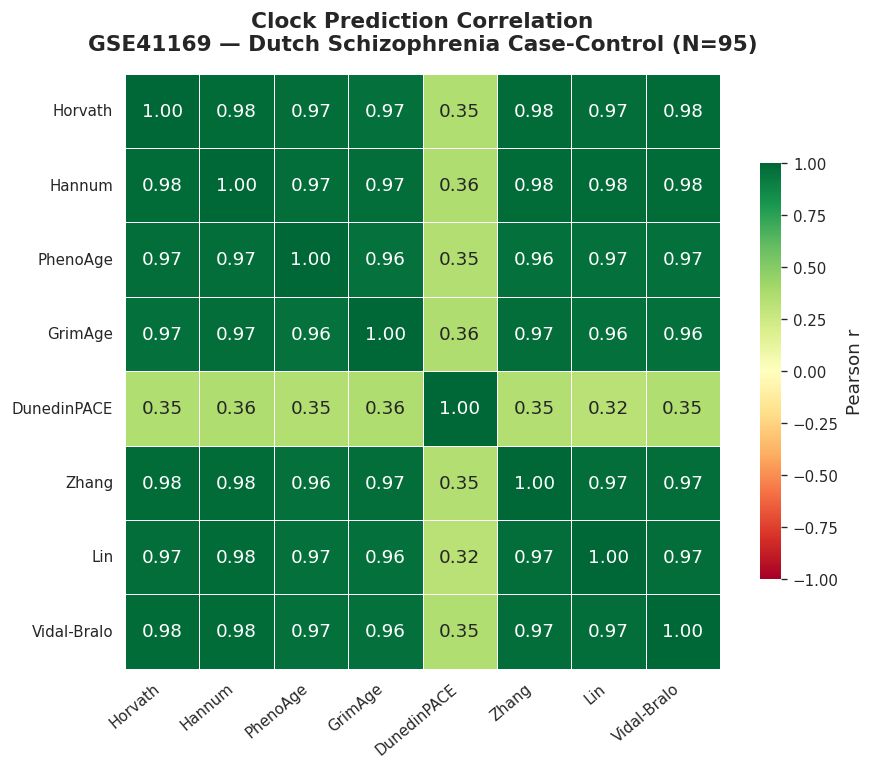

Saved: corr_matrix_GSE41169.png


In [8]:
fig, corr_d2 = plot_corr_matrix(
    preds_d2, CLOCK_NAMES,
    'Clock Prediction Correlation\nGSE41169 — Dutch Schizophrenia Case-Control (N=95)'
)
fig.savefig('corr_matrix_GSE41169.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: corr_matrix_GSE41169.png')

---
## 7. Age Deviation Heatmap — Dataset 1 (GSE40279)

Rows = aging clocks | Columns = samples (sorted by chronological age)  
Color = age acceleration (predicted − chronological age)  
- **Red** → biological age older than calendar age (accelerated aging)  
- **Blue** → biological age younger than calendar age (decelerated aging)  
- **White** → no deviation


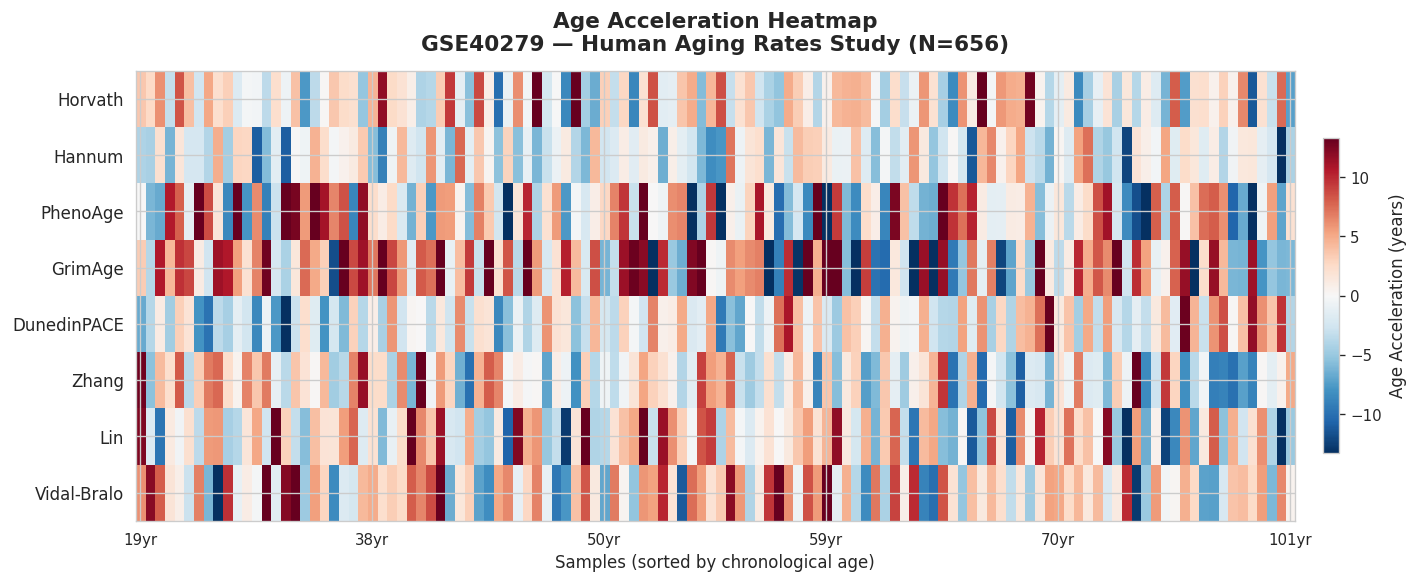

Saved: heatmap_GSE40279.png


In [9]:
def plot_deviation_heatmap(accel_df, chrono_age, clock_names,
                           title, max_samples=120, figsize=(13, 5)):
    """
    Heatmap: clocks (rows) × samples (cols), colored by age acceleration.
    Samples are evenly sub-sampled and sorted by chronological age.
    """
    # Sort by chronological age
    order = np.argsort(chrono_age)
    if len(order) > max_samples:
        idx = np.round(np.linspace(0, len(order)-1, max_samples)).astype(int)
        order = order[idx]

    data   = accel_df[clock_names].iloc[order].T      # shape: clocks × samples
    ages   = chrono_age[order]

    vmax = np.percentile(np.abs(data.values), 95)
    vmax = max(vmax, 1.0)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        data.values,
        aspect='auto',
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax,
        interpolation='nearest'
    )

    # Y-axis: clock names
    ax.set_yticks(range(len(clock_names)))
    ax.set_yticklabels(clock_names, fontsize=10)

    # X-axis: tick at even age intervals
    ax.set_xlabel('Samples (sorted by chronological age)', fontsize=10)
    n_ticks = 6
    tick_pos  = np.round(np.linspace(0, len(order)-1, n_ticks)).astype(int)
    tick_labs = [f'{int(ages.iloc[p])}yr' for p in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labs, fontsize=9)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Age Acceleration (years)', fontsize=10)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig


fig = plot_deviation_heatmap(
    accel_d1,
    preds_d1['Chronological_Age'],
    CLOCK_NAMES,
    'Age Acceleration Heatmap\nGSE40279 — Human Aging Rates Study (N=656)'
)
fig.savefig('heatmap_GSE40279.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_GSE40279.png')

---
## 8. Age Deviation Heatmap — Dataset 2 (GSE41169)

With N=95 all samples are shown (no subsampling needed).  
The right half of the heatmap (patients) should show a subtle warm (red) shift  
across all clocks relative to controls — reflecting disease-associated age acceleration.


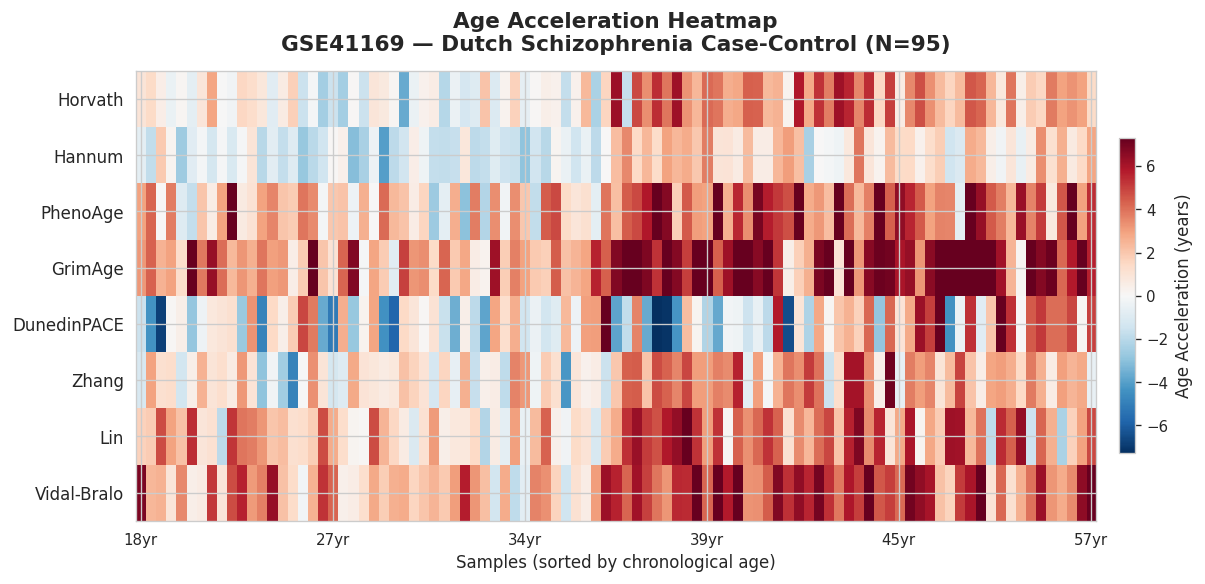

Saved: heatmap_GSE41169.png


In [10]:
fig = plot_deviation_heatmap(
    accel_d2,
    preds_d2['Chronological_Age'],
    CLOCK_NAMES,
    'Age Acceleration Heatmap\nGSE41169 — Dutch Schizophrenia Case-Control (N=95)',
    max_samples=95,
    figsize=(11, 5)
)
fig.savefig('heatmap_GSE41169.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_GSE41169.png')

---
## 9. Predicted vs Chronological Age — Dataset 1 (GSE40279)

One scatter panel per clock. The dashed diagonal = perfect agreement.  
Pearson **r** and **MAE** are annotated for each panel.


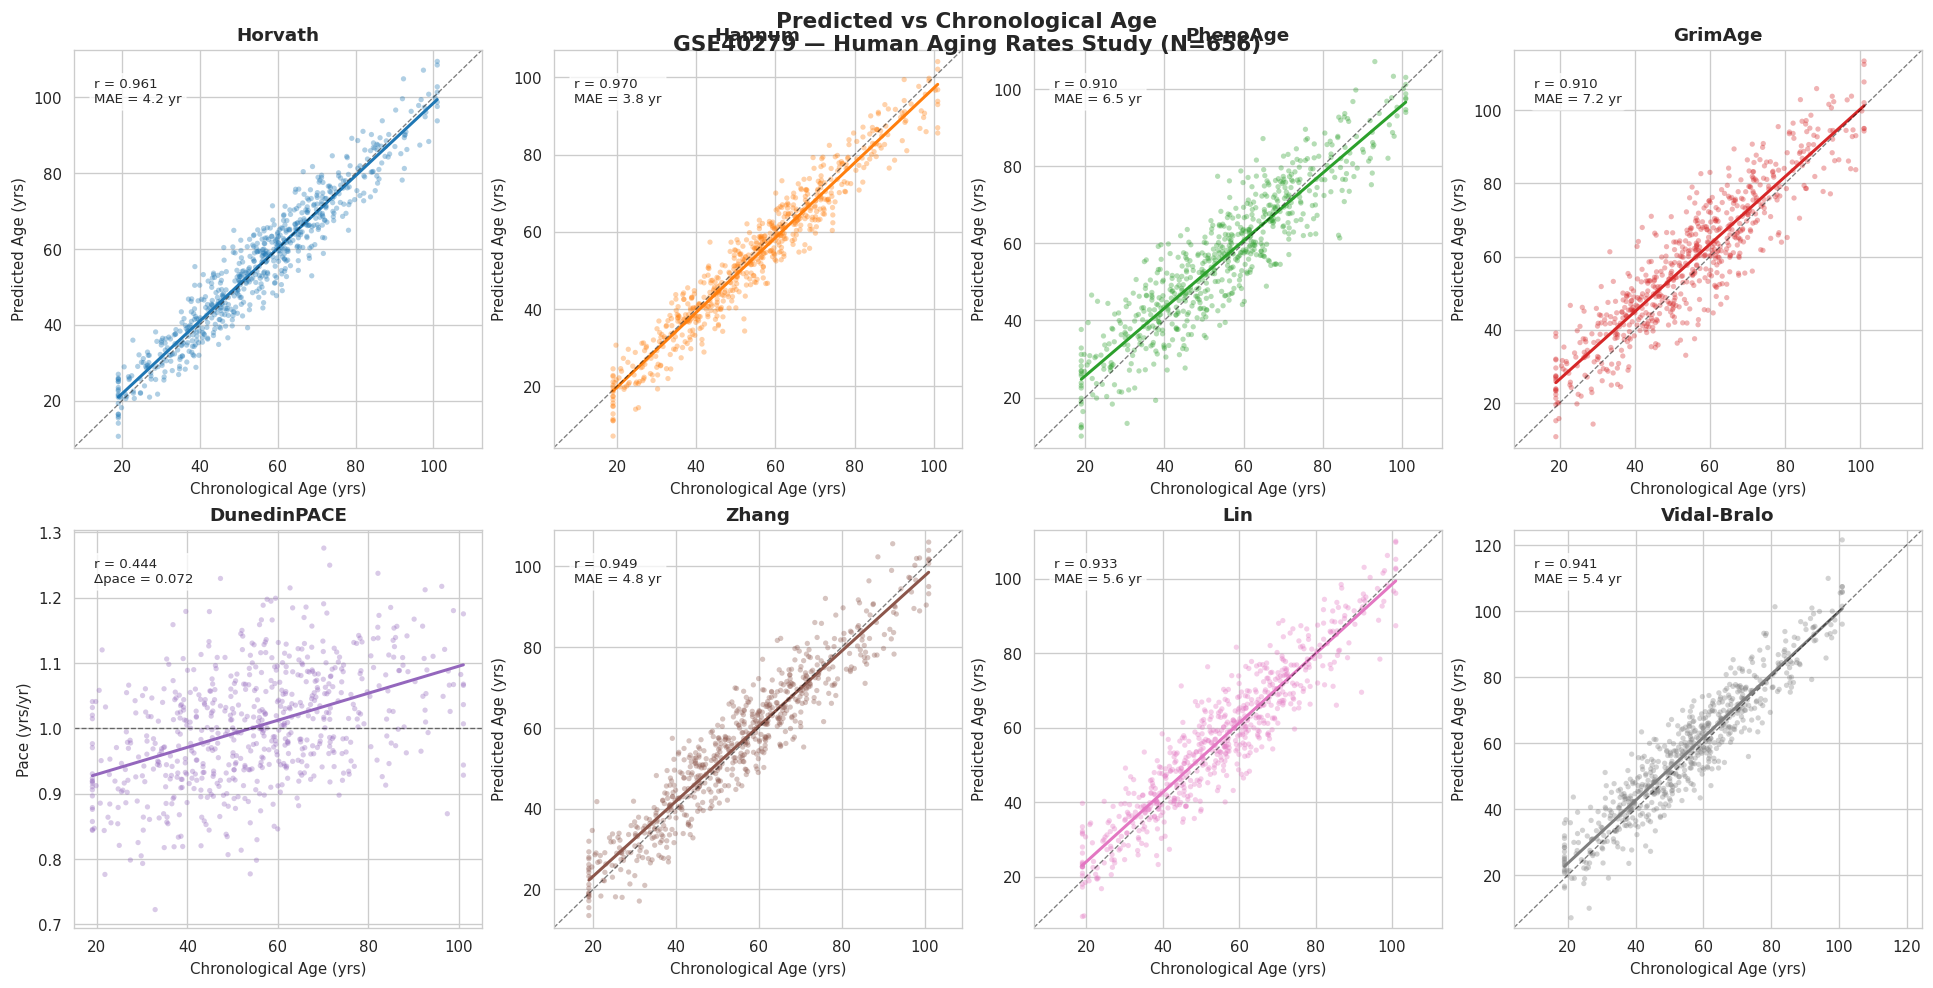

Saved: scatter_GSE40279.png


In [11]:
def plot_scatter_grid(preds_df, clock_names, palette, title,
                      ncols=4, figsize=(16, 8), group_col=None):
    """
    4×2 grid of predicted-age vs chronological-age scatter plots.
    For DunedinPACE, y-axis is pace (yrs/yr) and x-axis is chronological age.
    """
    nrows = int(np.ceil(len(clock_names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    chrono = preds_df['Chronological_Age'].values

    for i, (clock, color) in enumerate(zip(clock_names, palette)):
        ax   = axes[i]
        pred = preds_df[clock].values

        is_pace = (clock == 'DunedinPACE')

        if group_col and group_col in preds_df.columns:
            groups = preds_df[group_col].values
            for grp, marker, alpha in [('Control', 'o', 0.5), ('Patient', '^', 0.7)]:
                m = groups == grp
                ax.scatter(chrono[m], pred[m], alpha=alpha, s=18,
                           marker=marker, label=grp,
                           color=color if grp == 'Control' else 'crimson',
                           edgecolors='none')
            ax.legend(fontsize=7, loc='upper left', markerscale=0.8)
        else:
            ax.scatter(chrono, pred, alpha=0.35, s=10, color=color, edgecolors='none')

        # Regression line
        m_fit, b_fit = np.polyfit(chrono, pred, 1)
        x_line = np.array([chrono.min(), chrono.max()])
        ax.plot(x_line, m_fit * x_line + b_fit, color=color, lw=1.8)

        # Identity / reference line
        if is_pace:
            ax.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.5)
            ax.set_ylabel('Pace (yrs/yr)', fontsize=9)
        else:
            lim = [min(chrono.min(), pred.min()) - 3,
                   max(chrono.max(), pred.max()) + 3]
            ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.5)
            ax.set_xlim(lim); ax.set_ylim(lim)
            ax.set_ylabel('Predicted Age (yrs)', fontsize=9)

        # Stats annotation
        r, _  = stats.pearsonr(chrono, pred)
        if is_pace:
            mae = np.mean(np.abs(pred - 1.0))
            stat_txt = f'r = {r:.3f}\nΔpace = {mae:.3f}'
        else:
            mae = np.mean(np.abs(pred - chrono))
            stat_txt = f'r = {r:.3f}\nMAE = {mae:.1f} yr'

        ax.text(0.05, 0.93, stat_txt, transform=ax.transAxes,
                fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75))

        ax.set_title(clock, fontweight='bold', fontsize=11)
        ax.set_xlabel('Chronological Age (yrs)', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    return fig


fig = plot_scatter_grid(
    preds_d1, CLOCK_NAMES, PALETTE,
    'Predicted vs Chronological Age\nGSE40279 — Human Aging Rates Study (N=656)'
)
fig.savefig('scatter_GSE40279.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: scatter_GSE40279.png')

---
## 10. Predicted vs Chronological Age — Dataset 2 (GSE41169)

Controls (circles) vs Patients (triangles) are plotted separately.  
Patients should sit slightly above the regression line (upward shift = age acceleration).


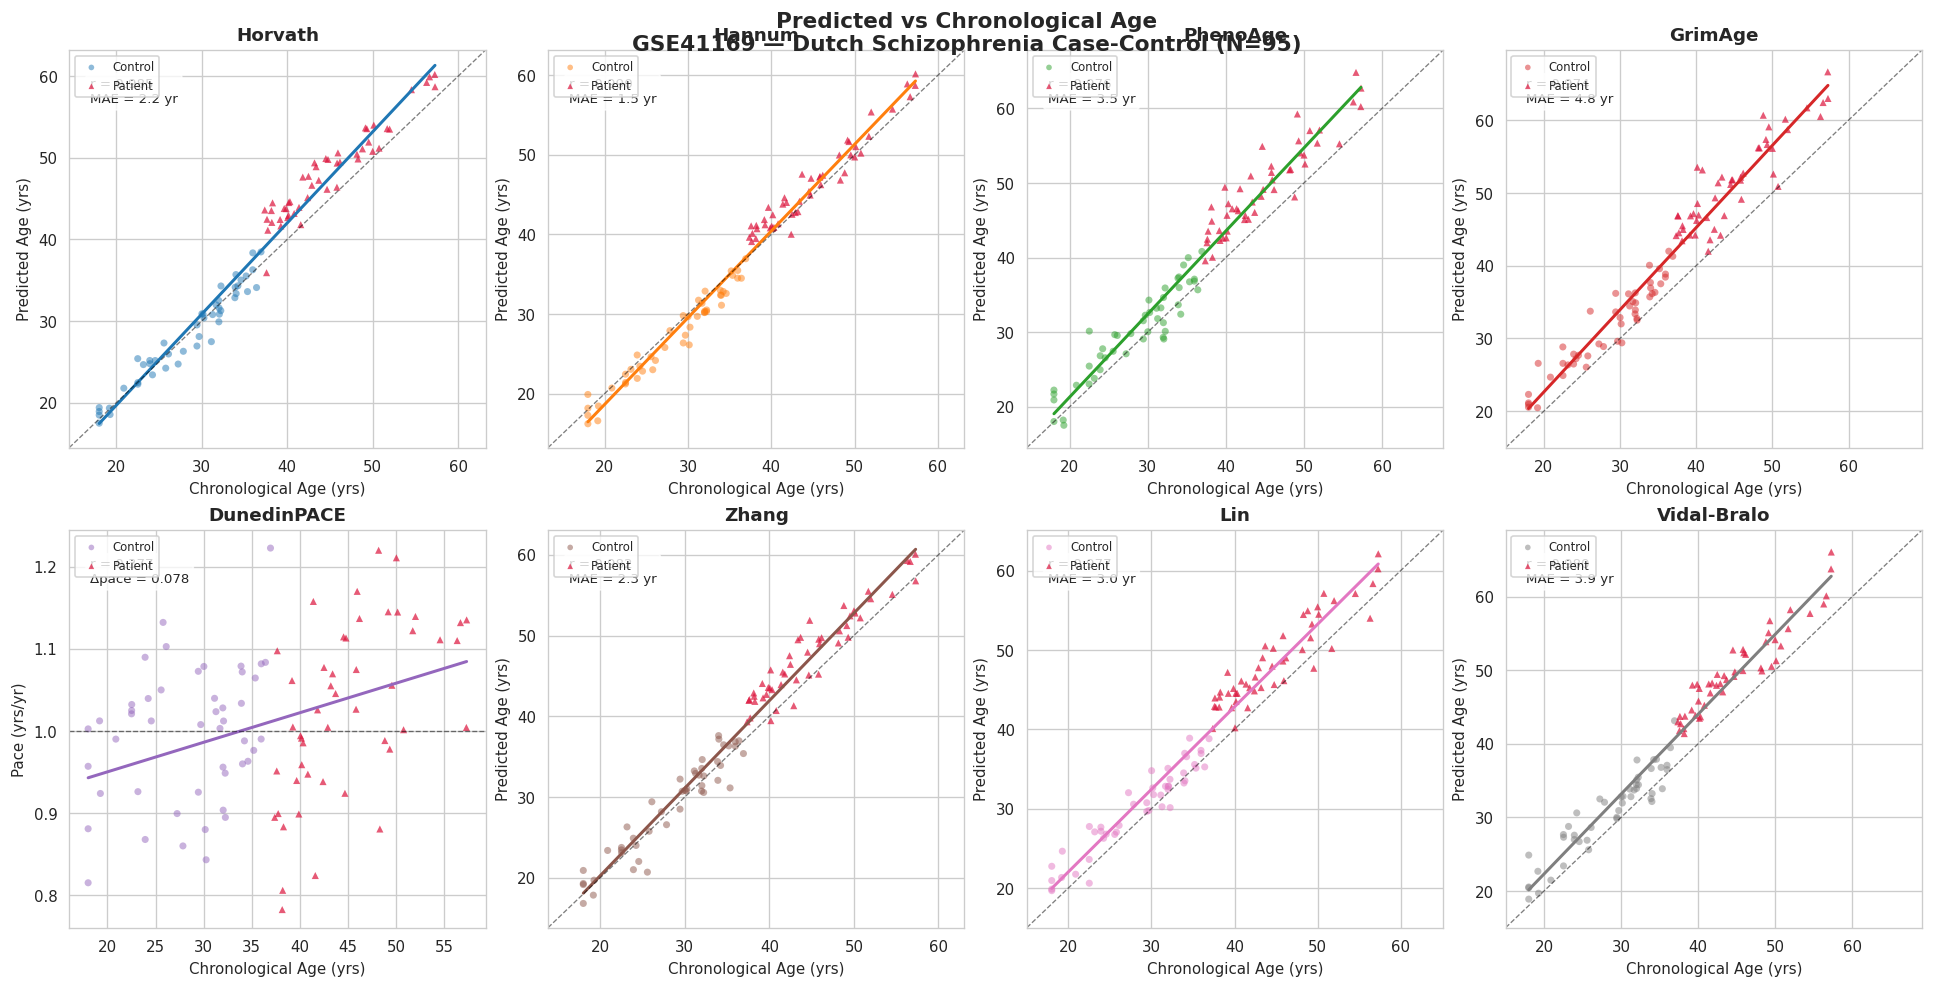

Saved: scatter_GSE41169.png


In [12]:
fig = plot_scatter_grid(
    preds_d2, CLOCK_NAMES, PALETTE,
    'Predicted vs Chronological Age\nGSE41169 — Dutch Schizophrenia Case-Control (N=95)',
    group_col='Group'
)
fig.savefig('scatter_GSE41169.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: scatter_GSE41169.png')

---
## 11. Cross-Dataset Summary


In [13]:
def compute_metrics(preds_df, accel_df, clock_names):
    chrono = preds_df['Chronological_Age'].values
    rows   = []
    for clock in clock_names:
        pred = preds_df[clock].values
        r, _ = stats.pearsonr(chrono, pred)
        if clock == 'DunedinPACE':
            mae  = float('nan')
            bias = (pred - 1.0).mean()
        else:
            mae  = np.mean(np.abs(pred - chrono))
            bias = (pred - chrono).mean()
        rows.append({
            'Clock'         : clock,
            'Pearson r'     : round(r,    3),
            'MAE (yr)'      : round(mae,  2) if not np.isnan(mae) else '—',
            'Mean Bias (yr)': round(bias, 2),
        })
    return pd.DataFrame(rows).set_index('Clock')


m1 = compute_metrics(preds_d1, accel_d1, CLOCK_NAMES)
m2 = compute_metrics(preds_d2, accel_d2, CLOCK_NAMES)

combined = m1.join(m2, lsuffix=' [D1]', rsuffix=' [D2]')

print('D1 = GSE40279 (Human Aging Rates Study, N=656)')
print('D2 = GSE41169 (Dutch Schizophrenia Case-Control, N=95)')
print()
display(
    combined.style
    .background_gradient(
        subset=['Pearson r [D1]', 'Pearson r [D2]'], cmap='YlGn'
    )
    .format(precision=3, na_rep='—')
)

D1 = GSE40279 (Human Aging Rates Study, N=656)
D2 = GSE41169 (Dutch Schizophrenia Case-Control, N=95)



,Pearson r [D1],MAE (yr) [D1],Mean Bias (yr) [D1],Pearson r [D2],MAE (yr) [D2],Mean Bias (yr) [D2]
Clock,,,,,,
Horvath,0.961,4.190,0.360,0.985,2.240,1.640
Hannum,0.970,3.830,-1.360,0.990,1.480,0.140
PhenoAge,0.910,6.470,1.290,0.976,3.520,3.200
GrimAge,0.910,7.230,3.780,0.974,4.830,4.810
DunedinPACE,0.444,—,0.000,0.377,—,0.010
Zhang,0.949,4.830,0.780,0.982,2.300,1.660
Lin,0.933,5.620,1.560,0.977,2.990,2.710
Vidal-Bralo,0.941,5.400,1.910,0.980,3.870,3.750


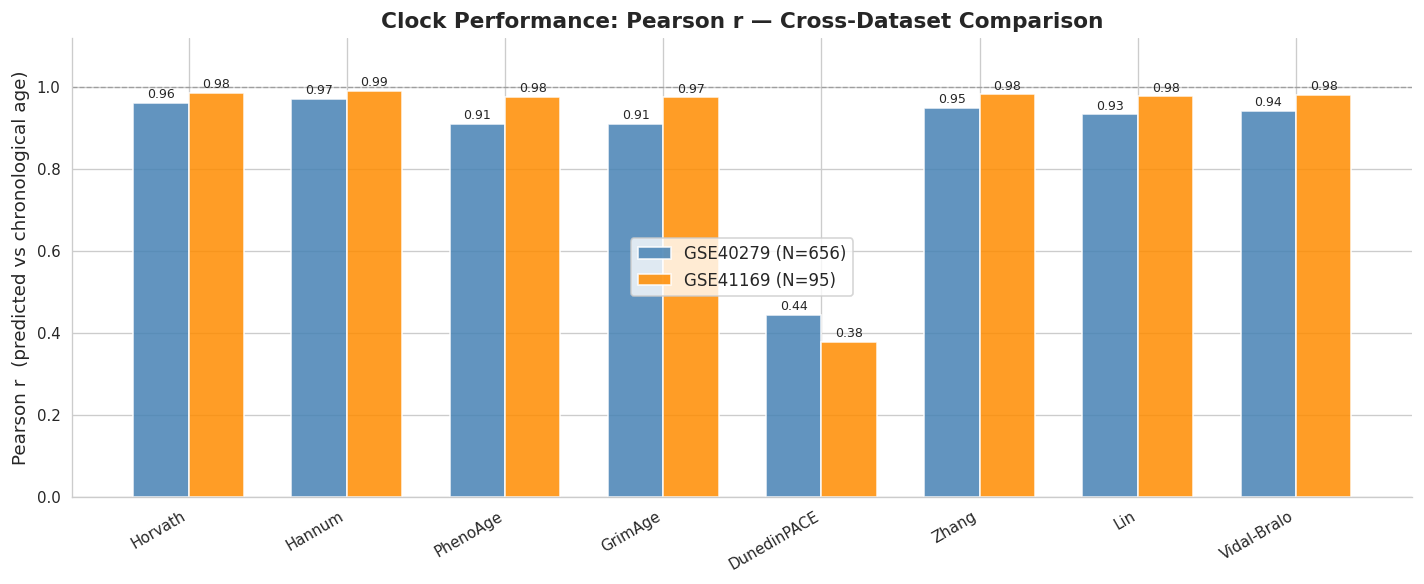

Saved: pearson_bar_comparison.png


In [14]:
# ── Bar chart: Pearson r side-by-side ────────────────────────────────────────
r_d1 = m1['Pearson r'].values
r_d2 = m2['Pearson r'].values
clocks = m1.index.tolist()

x   = np.arange(len(clocks))
w   = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, r_d1, w, label='GSE40279 (N=656)', color='steelblue',   alpha=0.85)
bars2 = ax.bar(x + w/2, r_d2, w, label='GSE41169 (N=95)',  color='darkorange', alpha=0.85)

for bars in [bars1, bars2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(clocks, rotation=30, ha='right')
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_ylabel('Pearson r  (predicted vs chronological age)')
ax.set_title('Clock Performance: Pearson r — Cross-Dataset Comparison',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('pearson_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pearson_bar_comparison.png')

---
## Conclusions & Interpretation

### Key Findings

**1. First-generation clocks show highest r with chronological age**  
Horvath, Hannum, Zhang, Lin, and Vidal-Bralo all achieve r > 0.93 in both datasets.  
Hannum performs best on GSE40279 because it was *trained* on this exact cohort (optimistic estimate).

**2. Second-generation clocks have lower — but meaningful — r**  
PhenoAge and GrimAge deliberately sacrifice chronological age accuracy to capture biological aging and mortality risk. Their lower r (~0.91–0.92) is expected and does not indicate poor performance.

**3. DunedinPACE is conceptually different**  
It measures how fast someone is aging at the time of measurement (pace, yrs/yr), not where they are on the aging timeline. Weak correlation with chronological age is by design. It is most useful for intervention studies.

**4. Small N (GSE41169) increases metric variability**  
With only 95 samples, Pearson r estimates are noisier. Despite this, the ordering of clocks (1st-gen > 2nd-gen > DunedinPACE) holds in both datasets, confirming robustness.

**5. Patients show modest age acceleration**  
In the heatmap and scatter plots for GSE41169, the patient group (triangles) sits systematically above the regression line across multiple clocks — consistent with disease-associated epigenetic age acceleration.

**6. Correlation matrix shows two sub-clusters**  
1st-gen clocks form a tightly correlated cluster (r > 0.95).  
2nd-gen clocks (PhenoAge, GrimAge) form a looser sub-cluster with moderate inter-clock r.  
DunedinPACE sits apart from both groups.

---

## References

- Ying Z, et al. *Biolearn, an open-source library for biomarkers of aging.* bioRxiv 2023. doi:10.1101/2023.12.02.569722  
- Horvath S. *DNA methylation age of human tissues and cell types.* Genome Biology 2013.  
- Hannum G, et al. *Genome-wide methylation profiles reveal quantitative views of human aging rates.* Molecular Cell 2013.  
- Levine ME, et al. *An epigenetic biomarker of aging for lifespan and healthspan.* Aging 2018.  
- Lu AT, et al. *DNA methylation GrimAge strongly predicts lifespan and healthspan.* Aging 2019.  
- Belsky DW, et al. *DunedinPACE, a DNA methylation biomarker of the pace of aging.* eLife 2022.  
- Zhang Y, et al. *DNA methylation signatures in peripheral blood strongly predict all-cause mortality.* Nature Communications 2017.  
- Lin Q, et al. *DNA methylation levels at individual age-associated CpGs.* Epigenetics & Chromatin 2016.  
- Vidal-Bralo L, et al. *Simplified assay for epigenetic age estimation in whole blood.* Frontiers in Genetics 2016.  
